# Capacitated Dispersion Problem: Case Study

## 1. Environment Setup
Importing necessary libraries for exact solving (Gurobi), data manipulation (Pandas/Numpy), and visualization (Matplotlib).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gurobipy as gp
from gurobipy import GRB
import subprocess
import os
import glob
import time
import time
import math

## 2. Helper Functions

### 2.1 Synthetic Instance Generator
Generates random planar instances to validate the solvers.

### 2.2 Solution Visualizer
Visualizes the selected nodes and the bottleneck edge (minimum distance) on a 2D plane.

In [3]:
def generate_synthetic_instance(n_nodes=100, capacity_threshold=0.2):
    np.random.seed(42)
    coords = np.random.rand(n_nodes, 2) * 100
    
    d = np.zeros((n_nodes, n_nodes))
    for i in range(n_nodes):
        for j in range(n_nodes):
            dist = np.linalg.norm(coords[i] - coords[j])
            d[i][j] = dist
            d[j][i] = dist
            
    q = np.random.randint(1, 100, size=n_nodes)
    
    B = int(np.sum(q) * capacity_threshold)
    
    return coords, d, q, B





def visualize_results(coords, solution_set, d, q, B, title, duration=None):
    sol_list = list(solution_set)
    if len(sol_list) < 2:
        print("Solution too small to visualize.")
        return

    n_selected = len(sol_list)
    
    selected_cap = sum(q[i] for i in sol_list)
    total_instance_cap = sum(q)
    
    min_dist = float('inf')
    bottleneck_edges = []
    
    for i in range(len(sol_list)):
        for j in range(i + 1, len(sol_list)):
            u, v = sol_list[i], sol_list[j]
            dist = d[u][v]
            if dist < min_dist:
                min_dist = dist
                bottleneck_edges = [(u, v)]
            elif math.isclose(dist, min_dist):
                bottleneck_edges.append((u, v))
    
    time_str = f"{duration:.4f}s" if duration is not None else "N/A"
    status_icon = "✔" if selected_cap >= B else "✘"
    
    line1 = f"Obj: {min_dist:.4f}  |  Time: {time_str}  |  Nodes: {n_selected}"

    line2 = f"Cap: {selected_cap:.0f} / {B:.0f} (Req)  [{status_icon}]  |  Instance Total: {total_instance_cap:.0f}"

    stats_text = f"{line1}\n{line2}"

    plt.figure(figsize=(12, 7))
    
    plt.scatter(coords[:, 0], coords[:, 1], c='lightgray', s=30, alpha=0.6, label='Ignored')
    
    selected_coords = coords[sol_list]
    plt.scatter(selected_coords[:, 0], selected_coords[:, 1], c='red', s=90, edgecolors='black', zorder=5, label='Selected')
    
    first_edge = True
    for u, v in bottleneck_edges:
        p1, p2 = coords[u], coords[v]
        label = f'Bottleneck ({min_dist:.4f})' if first_edge else ""
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color='green', linewidth=2.5, linestyle='-', zorder=4, label=label)
        first_edge = False
        
    plt.title(f"{title}\n{stats_text}", fontsize=11, pad=10, fontname='monospace')
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper right')
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    plt.savefig(f"plots/{title.replace(' ', '_')}.png", format='png', bbox_inches='tight')

    plt.show()

## 3. Exact Solver Implementation

Implementation of **Model 1 (Kuby, 1987)** using the Gurobi Optimizer. Used for validation & visualization only.

In [4]:
class CDP_Exact_Solver:
    def __init__(self, n_nodes, distances, capacities, min_capacity_B):
        self.n = n_nodes
        self.d = distances
        self.q = capacities
        self.B = min_capacity_B

    def calculate_capacity(self, solution_set):
        return sum(self.q[i] for i in solution_set)

    def solve_model_1_kuby(self, time_limit=60):
        print(f"--- Exact Solver: Model 1 (Kuby) ---")
        try:
            m = gp.Model("MILP1")
            m.setParam('TimeLimit', time_limit)
            m.setParam('OutputFlag', 0)

            x = m.addVars(self.n, vtype=GRB.BINARY, name="x")
            max_dist = np.max(self.d)
            d_bar = m.addVar(vtype=GRB.CONTINUOUS, lb=0.0, ub=max_dist, name="d_bar")

            m.setObjective(d_bar, GRB.MAXIMIZE)
            m.addConstr(gp.quicksum(self.q[i] * x[i] for i in range(self.n)) >= self.B, "Capacity")

            M = max_dist + 1.0
            for i in range(self.n):
                for j in range(i + 1, self.n):
                    dist_val = self.d[i][j]
                    m.addConstr(
                        d_bar <= dist_val + M * (1 - x[i]) + M * (1 - x[j]),
                        name=f"Disp_{i}_{j}"
                    )
            
            m.optimize()

            if m.Status in [GRB.OPTIMAL, GRB.TIME_LIMIT] and m.SolCount > 0:
                selected_nodes = {i for i in range(self.n) if x[i].X > 0.5}
                obj_val = d_bar.X
                return selected_nodes, obj_val
            else:
                return set(), 0.0

        except gp.GurobiError as e:
            print(f"Gurobi Error: {e}")
            return set(), 0.0

## 4. Validation: Exact vs. Heuristic

In this section, we generate a synthetic instance and solve it using the exact method to visually verify the problem constraints (capacity and dispersion).

Dataset: N=10, Demand B=116, Total Cap=581

>>> Running Gurobi (Exact)...
--- Exact Solver: Model 1 (Kuby) ---
Set parameter Username
Set parameter LicenseID to value 2736008
Academic license - for non-commercial use only - expires 2026-11-11
Set parameter TimeLimit to value 120

Results [Exact Model 1 (Kuby)]:
  Execution Time: 0.0261 seconds
  Selected Nodes: 2
  Selected Cap  : 122 (Required: 116)
  Objective f(S): 101.3477
----------------------------------------

>>> Running MNSA (C++)...

Results [MNSA (Heuristic)]:
  Execution Time: 0.0415 seconds
  Selected Nodes: 2
  Selected Cap  : 122 (Required: 116)
  Objective f(S): 101.3480
----------------------------------------


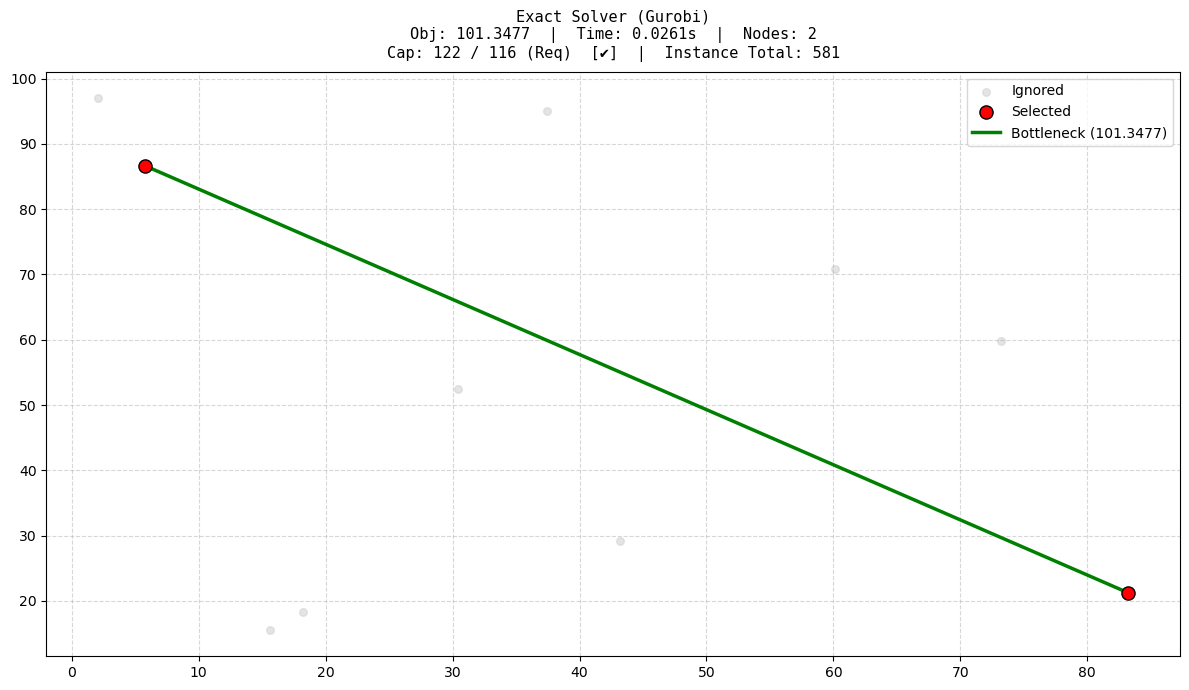

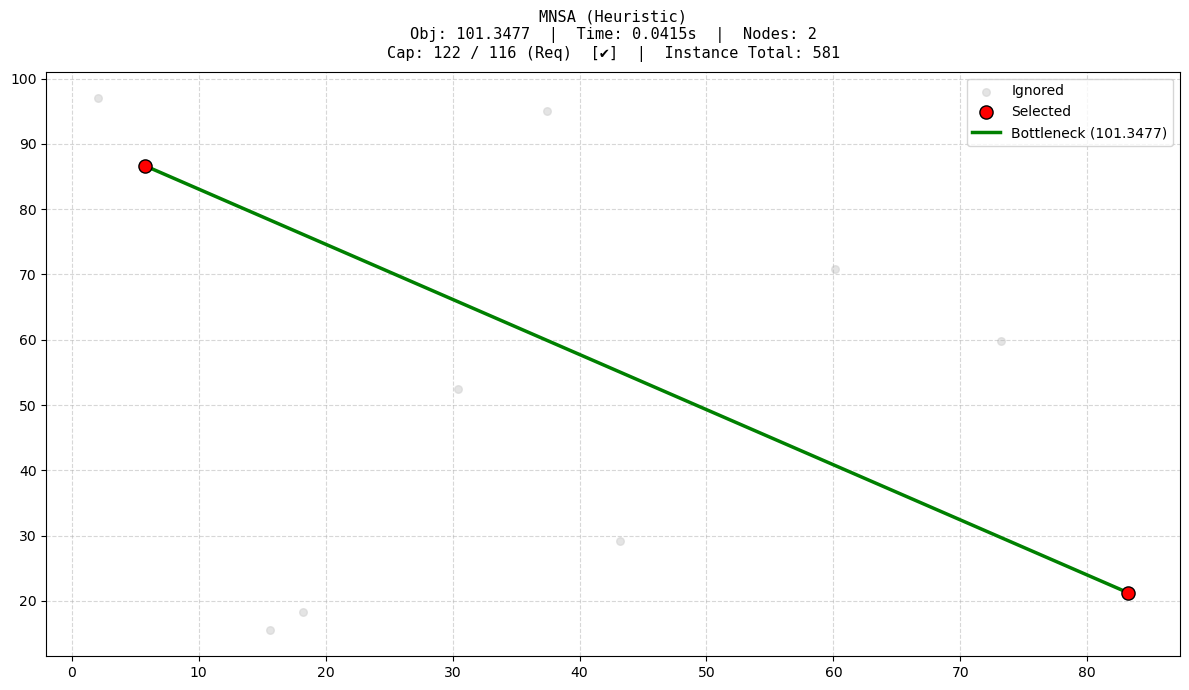

In [5]:
def print_solution_report(method_name, duration, solution, capacity, required_B, objective):
    print(f"\nResults [{method_name}]:")
    print(f"  Execution Time: {duration:.4f} seconds")
    print(f"  Selected Nodes: {len(solution)}")
    print(f"  Selected Cap  : {capacity} (Required: {required_B})")
    print(f"  Objective f(S): {objective:.4f}")
    print("-" * 40)

def run_cpp_solver_on_data(n, d, q, B, executable="./mnsa_turbo", time_limit=60):
    filename = "temp_synthetic.cdp"

    with open(filename, "w") as f:
        f.write(f"{n} {B}\n") 
        f.write(" ".join(map(str, q)) + "\n")
        
        for i in range(n):
            row_str = " ".join(f"{d[i][j]:.4f}" for j in range(n))
            f.write(f"{row_str}\n")

    # Pass "GIS" as mode arg, though extension detection should handle it
    cmd = [executable, filename, str(time_limit), "GIS", "0.0"] 
    
    start_t = time.time()
    try:
        process = subprocess.run(cmd, capture_output=True, text=True, check=True)
    except subprocess.CalledProcessError as e:
        print(f"C++ Error: {e.stderr}")
        return set(), 0.0, 0.0

    duration = time.time() - start_t
    
    # Parse Output (Matches your main.cpp print statements)
    obj_val = 0.0
    solution_set = set()
    
    lines = process.stdout.split('\n')
    for line in lines:
        if line.startswith("Objective:"):
            obj_val = float(line.split(":")[1].strip())
        elif line.startswith("Nodes:"):
            content = line.split(":")[1].strip()
            if content: 
                nodes = content.split(",")
                solution_set = {int(x) for x in nodes if x}

    if os.path.exists(filename):
        os.remove(filename)
        
    return solution_set, obj_val, duration

def compare_solvers_standardized():
    N = 10 
    coords, d, q, B = generate_synthetic_instance(n_nodes=N, capacity_threshold=0.2)
    
    print(f"Dataset: N={N}, Demand B={B}, Total Cap={np.sum(q)}")
    print("=" * 60)

    print("\n>>> Running Gurobi (Exact)...")
    exact_solver = CDP_Exact_Solver(N, d, q, B)
    start = time.time()
    sol_m1, obj_m1 = exact_solver.solve_model_1_kuby(time_limit=120)
    dur_m1 = time.time() - start
    
    print_solution_report(
        "Exact Model 1 (Kuby)", dur_m1, sol_m1, 
        exact_solver.calculate_capacity(sol_m1), B, obj_m1
    )
    
    print("\n>>> Running MNSA (C++)...")
    sol_mnsa, obj_mnsa, dur_mnsa = run_cpp_solver_on_data(
        N, d, q, B, executable="./mnsa_turbo", time_limit=60
    )
    
    cap_mnsa = sum(q[i] for i in sol_mnsa)
    
    print_solution_report(
        "MNSA (Heuristic)", dur_mnsa, sol_mnsa, 
        cap_mnsa, B, obj_mnsa
    )
    
    visualize_results(coords, sol_m1, d, q, B, "Exact Solver (Gurobi)", dur_m1)
    visualize_results(coords, sol_mnsa, d, q, B, "MNSA (Heuristic)", dur_mnsa)

if __name__ == "__main__":
    compare_solvers_standardized()

## 5. Large-Scale Benchmark Experiment

We now run the C++ implementation of the **Multi-Neighborhood Simulated Annealing (MNSA)** on the standard benchmark datasets (MDG-b and GIS).

* **MDG-b:** Challenging artificial instances (Non-Euclidean).
* **GIS:** Real-world instances based on road networks.

In [6]:
CPP_EXECUTABLE = "./mnsa_turbo"
INSTANCE_FOLDER_MDG = "benchmark_instances/MDG-b/"
INSTANCE_FOLDER_GIS = "benchmark_instances/GIS/"
TIME_LIMIT = 2880
NUM_RUNS = 10

def run_experiment():
    results = []
    
    files = glob.glob(os.path.join(INSTANCE_FOLDER_MDG, "*.*"))
    files.extend(glob.glob(os.path.join(INSTANCE_FOLDER_GIS, "*.*")))
    files = [f for f in files if f.endswith(".txt") or f.endswith(".cdp")]
    files.sort()
    
    print(f"--- Found {len(files)} files ---")
    
    for filepath in files:
        filename = os.path.basename(filepath)
        is_gis = filename.endswith(".cdp")
        
        alphas_to_run = [0.0] if is_gis else [0.2, 0.3]
        
        for alpha in alphas_to_run:
            mode_label = "GIS" if is_gis else f"MDG (Alpha={alpha})"
            print(f"\nProcessing {filename} [{mode_label}]")
            
            for run_id in range(1, NUM_RUNS + 1):
                try:
                    cmd = [CPP_EXECUTABLE, filepath, str(TIME_LIMIT), "AUTO", str(alpha)]
                    
                    start_t = time.time()
                    process = subprocess.run(cmd, capture_output=True, text=True, check=True)
                    duration = time.time() - start_t

                    obj_val = 0
                    sel_cap = 0
                    
                    for line in process.stdout.split('\n'):
                        if line.startswith("Objective:"): obj_val = float(line.split(":")[1])
                        elif line.startswith("Capacity:"): sel_cap = float(line.split(":")[1])

                    results.append({
                        "Instance": filename,
                        "Type": "GIS" if is_gis else "MDG",
                        "Alpha": "N/A" if is_gis else alpha,
                        "Run_ID": run_id,
                        "Objective": obj_val,
                        "Selected_Cap": sel_cap,
                        "Time": duration
                    })
                    print(f"  Run {run_id}: {obj_val:.2f}")
                    
                except Exception as e:
                    print(f"  Error: {e}")

    df = pd.DataFrame(results)
    df.to_csv("final_results.csv", index=False)
    print("\n--- Done. Saved to final_results.csv ---")

if __name__ == "__main__":
    run_experiment()

--- Found 4 files ---

Processing GIS-01.cdp [GIS]
  Run 1: 6.00
  Run 2: 6.00
  Run 3: 6.00
  Run 4: 6.00
  Run 5: 6.00
  Run 6: 5.00
  Run 7: 6.00
  Run 8: 6.00
  Run 9: 6.00
  Run 10: 6.00

Processing GIS-02.cdp [GIS]


KeyboardInterrupt: 

## 6. Results Analysis

Loading the results from the C++ execution and displaying the summary table.

In [ ]:
if os.path.exists("final_results_1.csv"):
    df_results = pd.read_csv("final_results_1.csv")
    display(df_results)
else:
    print("No results file found. Please run the experiment cell above.")

,Instance,Type,Alpha,Run_ID,Objective,Selected_Cap,Time
0,GIS-01.cdp,GIS,NaN,1,6.00,947483.0,44.064002
1,MDG-b_1_n500_m50.txt,MDG,0.2,1,58.22,539.0,2.461889
2,MDG-b_1_n500_m50.txt,MDG,0.3,1,26.72,810.0,5.102352


## 7. Comparison with Best Known Results (BKR)

Comparing our MNSA results against the state-of-the-art values reported in the literature (Rosati & Schaerf, 2024).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

RESULTS_FILE = "final_results_1.csv"

bkr_database = {
    ("MDG-b_1_n500_m50.txt", 0.2): 57.23,

    ("MDG-b_1_n500_m50.txt", 0.3): 27.73,
    
    ("GIS-01.cdp", "N/A"): 6.00,
}

if os.path.exists(RESULTS_FILE):
    df = pd.read_csv(RESULTS_FILE)
    
    def get_bkr(row):
        alpha_key = row['Alpha']
        try:
            if str(alpha_key) != "nan" and str(alpha_key) != "N/A":
                alpha_key = float(alpha_key)
        except:
            pass
            
        key = (row['Instance'], alpha_key)
        return bkr_database.get(key, None)

    df['BKR'] = df.apply(get_bkr, axis=1)
    
    df['Gap (%)'] = df.apply(
        lambda x: ((x['BKR'] - x['Objective']) / x['BKR'] * 100) 
        if (pd.notnull(x['BKR']) and x['BKR'] != 0) else np.nan, 
        axis=1
    )

    cols = ['Type', 'Instance', 'Alpha', 'Objective', 'BKR', 'Gap (%)', 'Time']
    df_final = df[cols].copy()

    df_final.to_csv("comparison_table.csv", index=False)
    print("✔ CSV saved: comparison_table.csv")

    try:
        def highlight_gap(val):
            if pd.isna(val): return ''
            if val <= 0: return 'background-color: #d4edda; color: green'
            if val < 2.0: return 'background-color: #fff3cd; color: orange'
            return 'background-color: #f8d7da; color: red'

        styler = df_final.style
        if hasattr(styler, "map"):
            styler = styler.map(highlight_gap, subset=['Gap (%)'])
        else:
            styler = styler.applymap(highlight_gap, subset=['Gap (%)'])
            
        display(styler.format({'Objective': '{:.2f}', 'BKR': '{:.2f}', 'Gap (%)': '{:.2f}%', 'Time': '{:.2f}s'}))
    except NameError:
        print(df_final.to_string())
    except Exception as e:
        print(f"Could not display styled table: {e}")
        print(df_final)

else:
    print(f"Error: '{RESULTS_FILE}' not found. Please run the experiment cell first.")

✔ CSV saved: comparison_table.csv
Could not display styled table: The '.style' accessor requires jinja2
  Type              Instance  Alpha  Objective    BKR   Gap (%)       Time
0  GIS            GIS-01.cdp    NaN       6.00    NaN       NaN  44.064002
1  MDG  MDG-b_1_n500_m50.txt    0.2      58.22  57.23 -1.729862   2.461889
2  MDG  MDG-b_1_n500_m50.txt    0.3      26.72  27.73  3.642265   5.102352


--- Starting Scalability Analysis (N=[10, 20, 30, 50, 100, 150, 250, 500]) ---
Processing N=10... --- Exact Solver: Model 1 (Kuby) ---
Set parameter TimeLimit to value 60
Done. (Gap: -0.00%)
Processing N=20... --- Exact Solver: Model 1 (Kuby) ---
Set parameter TimeLimit to value 60
Done. (Gap: 29.00%)
Processing N=30... --- Exact Solver: Model 1 (Kuby) ---
Set parameter TimeLimit to value 60
Done. (Gap: 9.36%)
Processing N=50... --- Exact Solver: Model 1 (Kuby) ---
Set parameter TimeLimit to value 60
Done. (Gap: 3.06%)
Processing N=100... --- Exact Solver: Model 1 (Kuby) ---
Set parameter TimeLimit to value 60
Done. (Gap: 0.00%)
Processing N=150... --- Exact Solver: Model 1 (Kuby) ---
Set parameter TimeLimit to value 60
Done. (Gap: 6.72%)
Processing N=250... --- Exact Solver: Model 1 (Kuby) ---
Set parameter TimeLimit to value 60
Done. (Gap: 1.16%)
Processing N=500... --- Exact Solver: Model 1 (Kuby) ---
Set parameter TimeLimit to value 60
Done. (Gap: 3.74%)


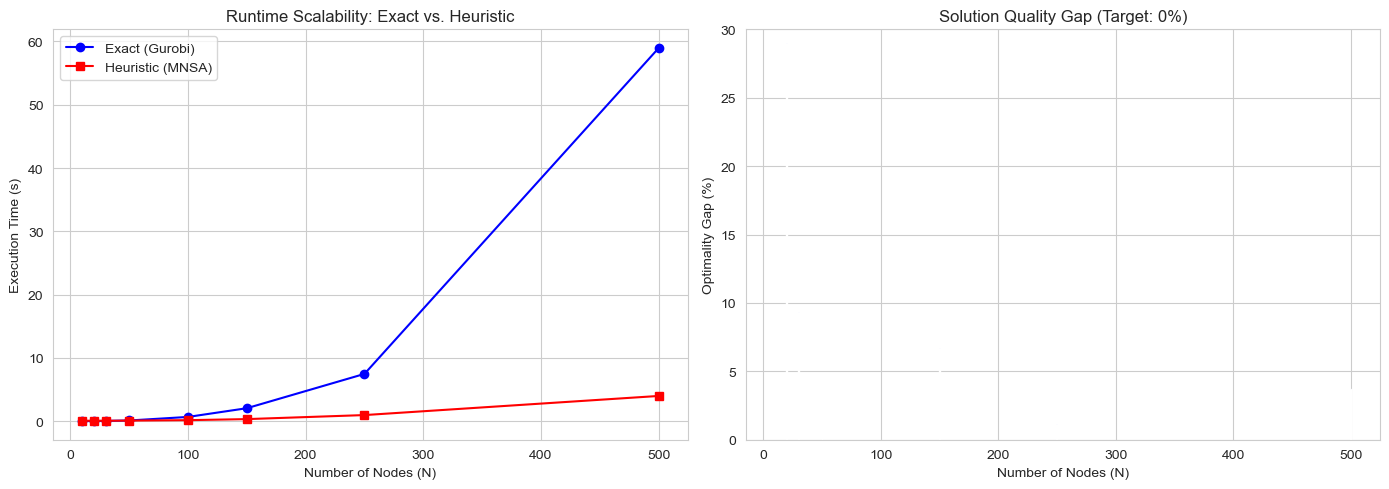


Analysis Complete. Saved plot to 'scalability_analysis.png'


In [ ]:
SCALABILITY_SIZES = [10, 20, 30, 50, 100, 150, 250, 500]

def run_scalability_analysis():
    results = []
    print(f"--- Starting Scalability Analysis (N={SCALABILITY_SIZES}) ---")
    
    for n in SCALABILITY_SIZES:
        print(f"Processing N={n}...", end=" ")
        
        coords, d, q, B = generate_synthetic_instance(n_nodes=n, capacity_threshold=0.2)
        
        exact_solver = CDP_Exact_Solver(n, d, q, B)
        start_t = time.time()
        _, obj_exact = exact_solver.solve_model_1_kuby()
        time_exact = time.time() - start_t
        
        sol_mnsa, obj_mnsa, time_mnsa = run_cpp_solver_on_data(
            n, d, q, B, executable="./mnsa_turbo",
        )

        gap = 0.0
        if obj_exact > 0:
            gap = (obj_exact - obj_mnsa) / obj_exact * 100
            
        results.append({
            "N": n,
            "Time_Exact": time_exact,
            "Time_MNSA": time_mnsa,
            "Obj_Exact": obj_exact,
            "Obj_MNSA": obj_mnsa,
            "Gap_Pct": gap
        })
        print(f"Done. (Gap: {gap:.2f}%)")

    df_scale = pd.DataFrame(results)
    
    sns.set_style("whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(df_scale["N"], df_scale["Time_Exact"], marker='o', label="Exact (Gurobi)", color='blue')
    ax1.plot(df_scale["N"], df_scale["Time_MNSA"], marker='s', label="Heuristic (MNSA)", color='red')
    ax1.set_xlabel("Number of Nodes (N)")
    ax1.set_ylabel("Execution Time (s)")
    ax1.set_title("Runtime Scalability: Exact vs. Heuristic")
    ax1.legend()
    
    plt.tight_layout()
    plt.savefig("scalability_analysis.png", dpi=300)
    plt.show()
    
    df_scale.to_csv("scalability_data.csv", index=False)
    print("\nAnalysis Complete. Saved plot to 'scalability_analysis.png'")

if __name__ == "__main__":
    run_scalability_analysis()